<a href="https://colab.research.google.com/github/kny1209/test2/blob/main/AI/%EA%B0%95%EC%9D%98_8%EA%B8%B0_AI%EC%9D%91%EC%9A%A9_01%EC%B0%A8%EC%8B%9C_03_OpenCV%20%ED%95%84%ED%84%B0%EB%A7%81.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
path = '/content/drive/MyDrive/puppy.jpg'

In [3]:
import os
import numpy as np
import cv2

import matplotlib.pyplot as plt
%matplotlib inline

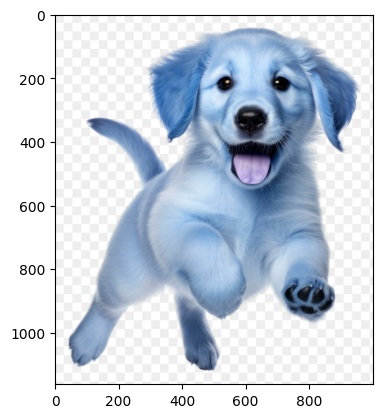

In [7]:
image = cv2.imread(path)

plt.imshow(image)
plt.show()

# 원본

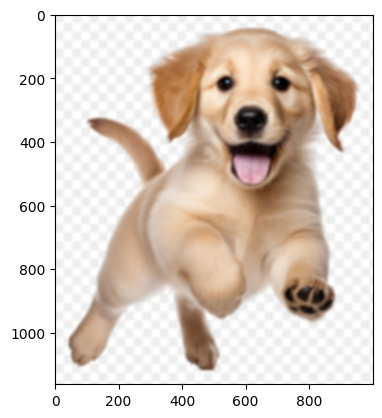

In [8]:
image = cv2.imread(path)

src = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

dst = cv2.blur(src, (11,11))
# blur(적용할 이미지, 커널 크기) : 평균 블러 적용
# 모든 픽셀에 대해 동일한 가중치 부여

plt.imshow(dst)
plt.show()

커널크기에 따라 blur 효과가 달라짐
- 3*3 커널 : 약간 흐림
- 5*5 커널: 중간적 흐림
- 11*11 커널 : 많이 흐림


왜 이런 일이?
- 작은 커널(3*3) : 주변에 9개 픽셀의 평균
  - 가까운 픽셀만 영향을 받음


- 큰 커널(11*11) : 주변에 121개 픽셀의 평균
  - 멀리 있는 픽셀도 영향을 받음

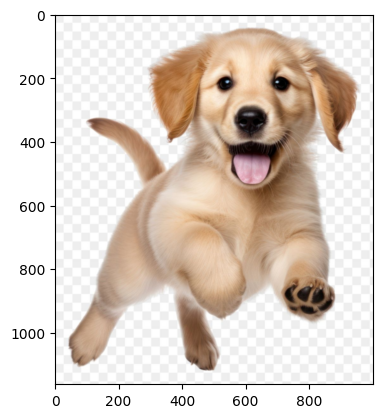

In [9]:
dst = cv2.blur(src, (3,3))
# blur(적용할 이미지, 커널 크기) : 평균 블러 적용
# 모든 픽셀에 대해 동일한 가중치 부여

plt.imshow(dst)
plt.show()

커널 크기 규칙
- 홀수만 사용
- 실제 사용 (3,3), (5,5), (7,7), (11,11)
- 홀수만 쓰는 이유 : 중앙(값)이 명확 (명확한 중심점이 존재)

가우시안 블럭 (GaussianBlur())

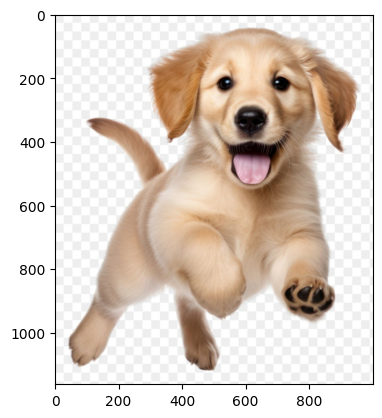

In [14]:
dst = cv2.GaussianBlur(src, ksize=(3,3), sigmaX=0)
# ksize=(3,3) 커널 사이즈
# sigmaX=0 >> 0이 기본값 (openCV가 자동 계산)
plt.imshow(dst)
plt.show()
# GaussianBlur 특징
# >> 중앙 픽셀에 더 큰 가중치 부여 (가장 많이 사용)

medianBlur() 중위수 블러

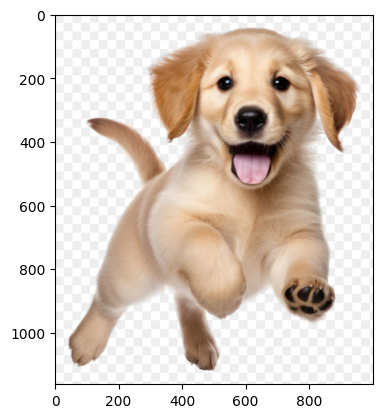

In [16]:
# nedianBlur (중위수) 사용 : 평균의 큰 단점인 이상치에 강함
# >> 이미지에서 이상치란 noise

dst = cv2.medianBlur(src, ksize=3)
plt.imshow(dst)
plt.show()

침식(erosion), 팽창(dilate), 열기(opening), 닫기(closing)

In [38]:
path = '/content/drive/MyDrive/salt.jpg'

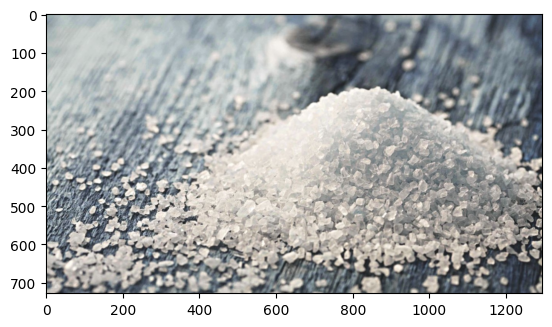

In [39]:
src = cv2.imread(path)
plt.imshow(src)
plt.show()

200.0


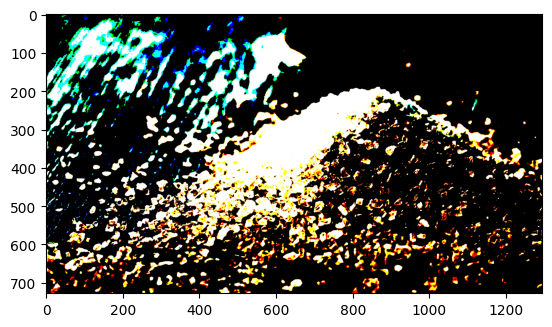

In [40]:
# 이진화 (binary) 0, 1 >> 흑백 / 임계치(기준값) 넘으면 255(흰색), 모자라면 0 (검은색)
# cv2.threshold(적용할 이미지, 임계값(기준값))
# >> 기준을 넘으면 ?? 255로 만들어라

result, binary_image = cv2.threshold(src, 200, 255, cv2.THRESH_BINARY)
# 200 : 임계값(기준값)을 넘으면 255(흰색)으로 만들어라
print(result)
plt.imshow(binary_image)
plt.show()

120.0


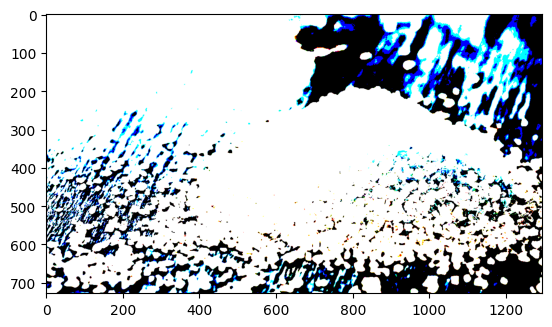

In [41]:
result, binary_image = cv2.threshold(src, 120, 255, cv2.THRESH_BINARY)
# 120 : 임계값(기준값)을 넘으면 255(흰)
print(result)
plt.imshow(binary_image)
plt.show()

149.0


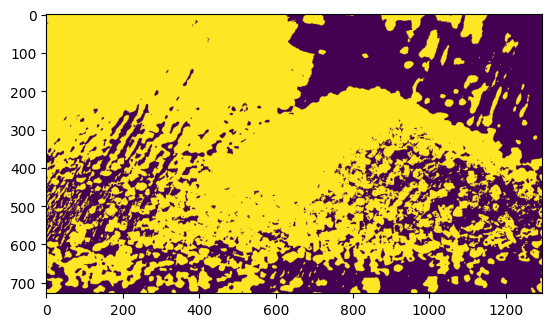

In [42]:
# otsu 알고리즘 사용
# 임계값 직접 설정 힘들어. 컴퓨터 너가 알아서 해
# 이미지가 GRAYSCALE 흑백사진이여야 함


src_gray = cv2.imread(path, cv2.IMREAD_GRAYSCALE)


# 임계값 0 설정하고 THRESH_OTSU 더함
result, binary_image_otsu = cv2.threshold(src_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print(result)
# 149.0 여기서 나온 result 값은 컴퓨터가 찾아줌 최적의 threshold
plt.imshow(binary_image_otsu)
plt.show()


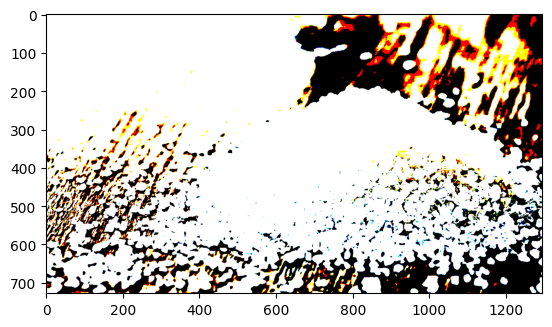

In [43]:
plt.imshow(cv2.cvtColor(binary_image, cv2.COLOR_BGR2RGB))
plt.show()

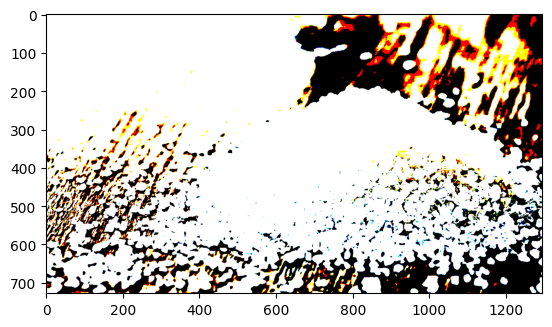

In [44]:
plt.imshow(cv2.cvtColor(binary_image, cv2.COLOR_BGR2RGB), cmap='gray')
plt.show()

커널 만들기

In [50]:
# np.empty(사이즈), np.zeros(사이즈)
# >> 사이즈 크기 만큼 비어있는 객체 생성 / 사이즈 크기만큼 0으로 채워진 객체 생성

kernel_1 = np.ones((3,3), np.uint8)
kernel_1

array([[1, 1, 1],
       [1, 1, 1],
       [1, 1, 1]], dtype=uint8)

In [51]:
kernel_0 = np.zeros((3,3), np.uint8)
kernel_0

array([[0, 0, 0],
       [0, 0, 0],
       [0, 0, 0]], dtype=uint8)

팽창과 침식 적용

- erosion 침식
  - 흰색 영역(255)의 외곽을 깍아내는 연산
  - 커널이 완전히 흰색을 포함하는 영역만 유지, 나머지는 검정(0)으로 바꿔요
  - 객체가 작아져요(외곽이 깍였으니깐), 작은 노이즈 제거(작은 점 형태 흰색 잡음 제거)


- dialtion 확대(팽창)
  - 흰색 영역(255) 넓혀줘요
  - 커널이 1개 라도 흰색 만나면 중심 픽셀을 흰색으로 확장
  - 객체가 커져요(빈 공간 채워줘요), 끊긴 선 연결(문자, 윤곽선 연결), 구멍 채워줘요

실무 TIP)


1. Binary(0-255)
2. erosion(줄어들고 잡음 제거) 또는 dailtion(커짐, 끊김 영역 연결)


- 일반적으로 외부 노이즈가 문제면, opening 사용
- 내부 구멍이 문제면 closing 사용
- 둘 다 문제면 opening 사용 후, closing

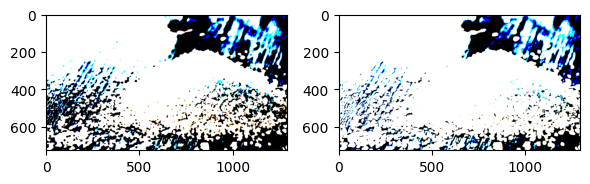

In [52]:
erode_image = cv2.erode(binary_image, kernel_1, iterations=1)
# 침식된 이미지

dialte_image = cv2.dilate(binary_image, kernel_1, iterations=1)
# 팽창된 이미지

fig, axes = plt.subplots(1,2,figsize=(6,3))

axes[0].imshow(erode_image)
axes[1].imshow(dialte_image)

plt.tight_layout()
plt.show()

- opening = erosion >> dilation (점 noise 빼고, 구멍 채워)
  - noise 제거한 후, 모형 유지
- closing = dilation >> erosion
  - 끊긴 윤곽선 연결, 구멍 채움

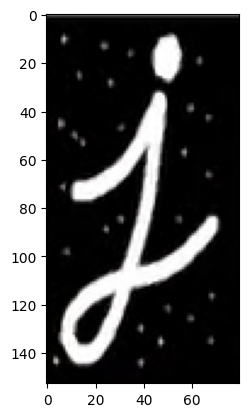

In [73]:
src_opening = cv2.imread('/content/drive/MyDrive/noisy.png')
plt.imshow(src_opening)
plt.show()

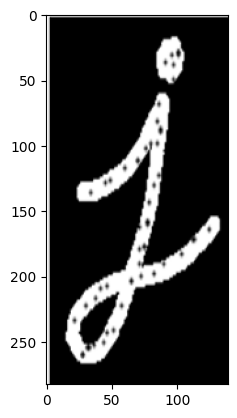

In [74]:
src_closing = cv2.imread('/content/drive/MyDrive/noisy_closing.png')
plt.imshow(src_closing)
plt.show()

120.0


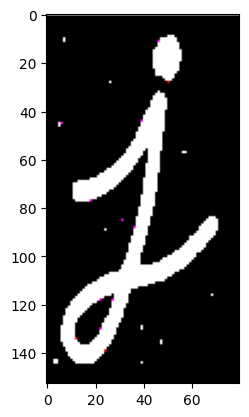

In [75]:
# 이진화 (binary) 0 또는 1 (흑백)
# 임계값(기준) 넘으면 255(흰색), 모자라면 0(검은색)
# cv2.threshold(적용할 이미지, 임계값(기준))
# >> 기준 넘기면, 255(흰색) 만들어줘

result, binary_image_open = cv2.threshold(src_opening, 120, 255, cv2.THRESH_BINARY)
result, binary_image_close = cv2.threshold(src_closing, 120, 255, cv2.THRESH_BINARY)

print(result) # 직접 threshold 설정 >> 설정한 값 출력
plt.imshow(binary_image_open)
plt.show()

120.0


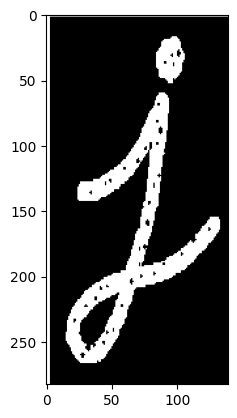

In [76]:
print(result) # 직접 threshold 설정 >> 설정한 값 출력
plt.imshow(binary_image_close)
plt.show()

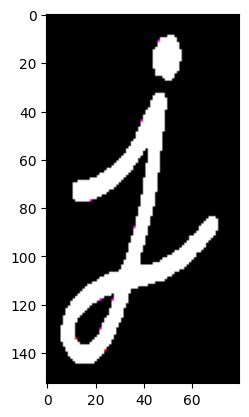

In [77]:
# 커널 만들기
kernel = np.ones((3,3), np.uint8)

# 열기 (opening)
opening = cv2.morphologyEx(binary_image_open, cv2.MORPH_OPEN, kernel, iterations=1)
# opening : 침식 후, 팽창

plt.imshow(opening)
plt.show()

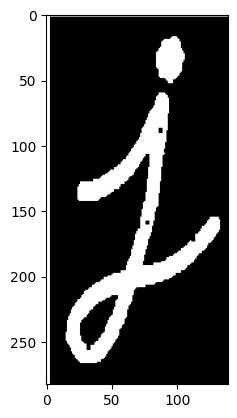

In [78]:
# 닫기 (closing)
closing = cv2.morphologyEx(binary_image_close, cv2.MORPH_CLOSE, kernel, iterations=1)
# closing : 팽창 후, 침식

plt.imshow(closing)
plt.show()

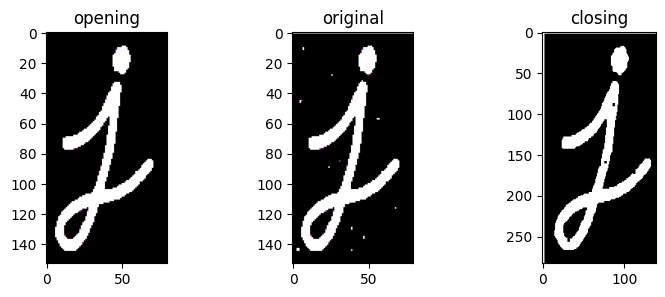

In [79]:
fig, axes = plt.subplots(1,3, figsize=(9,3))

axes[0].imshow(opening)
axes[0].set_title('opening')

axes[1].imshow(binary_image_open)
axes[1].set_title('original')

axes[2].imshow(closing)
axes[2].set_title('closing')

plt.show()